<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Collapse001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

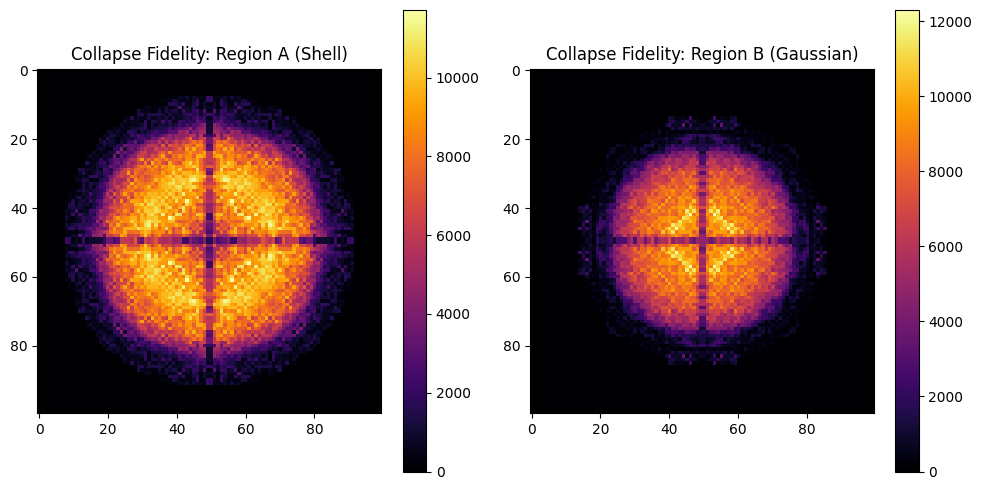

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Collapse001: Entropic Contagion — Shell + Gaussian

# Parameters
N = 100
timesteps = 500
alpha = 2.0
beta = 0.1

# Region masks
def region_mask(N, region="A"):
    mask = np.zeros((N, N, N), dtype=bool)
    if region == "A":  # Shell region (left half)
        mask[:N//2,:,:] = True
    elif region == "B":  # Gaussian region (right half)
        mask[N//2:,:,:] = True
    return mask

# Entropy initialization
def shell_entropy(N):
    x = np.linspace(-1, 1, N)
    grid = np.meshgrid(x, x, x)
    r = np.sqrt(sum(g**2 for g in grid))
    shell = np.exp(-((r - 0.5)**2) * 20)
    mask = region_mask(N, "A")
    return shell * mask

def gaussian_entropy(N):
    x = np.linspace(-1, 1, N)
    grid = np.meshgrid(x, x, x)
    r2 = sum(g**2 for g in grid)
    gaussian = np.exp(-5 * r2)
    mask = region_mask(N, "B")
    return gaussian * mask

# Collapse function with regional tracking
def simulate_contagion(entropy, alpha, beta):
    collapsed_A = np.zeros_like(entropy)
    collapsed_B = np.zeros_like(entropy)
    mask_A = region_mask(N, "A")
    mask_B = region_mask(N, "B")

    for t in range(timesteps):
        gradient = np.gradient(entropy)
        magnitude = np.sqrt(sum(g**2 for g in gradient))
        non_zero_mag = magnitude[magnitude > 1e-9]
        if non_zero_mag.size == 0:
            adaptive_threshold = 0.0
        else:
            mu_grad = np.mean(non_zero_mag)
            sigma_grad = np.std(non_zero_mag)
            adaptive_threshold = alpha * mu_grad + beta * sigma_grad

        collapse_mask = magnitude > adaptive_threshold
        entropy[collapse_mask] *= 0.9

        collapsed_A += collapse_mask * mask_A
        collapsed_B += collapse_mask * mask_B

        if np.sum(entropy) < 1e-6:
            break

    return collapsed_A, collapsed_B

# Initialize combined entropy field
entropy = shell_entropy(N) + gaussian_entropy(N)

# Run simulation
collapse_A, collapse_B = simulate_contagion(entropy.copy(), alpha, beta)

# Plot results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.sum(collapse_A, axis=0), cmap='inferno')
plt.title("Collapse Fidelity: Region A (Shell)")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(np.sum(collapse_B, axis=0), cmap='inferno')
plt.title("Collapse Fidelity: Region B (Gaussian)")
plt.colorbar()
plt.tight_layout()
plt.show()
